# Revisiting the Random Walk Metropolis Algorithm

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

Let us recall the random walk Metropolis algorithm. Consider the problem of generating samples from the following unnormalized univariate density. 

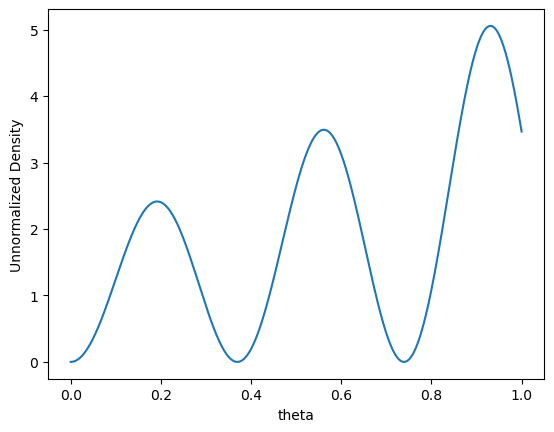

In [3]:
def f(th): 
    return (np.sin(8.5 * th) ** 2) * (th >= 0) * (th <= 1) * 2*np.exp(th)

th = np.arange(0, 1.001, 0.001)
plt.plot(th, f(th))
plt.xlabel("theta")
plt.ylabel("Unnormalized Density")
plt.show()

The integral of this function can be calculated as follows. 

In [4]:
from scipy.integrate import quad
val, err = quad(f, 0, 1)
print(val)

1.8775056565536072


Below is the Random-Walk Metropolis (RWM) algorithm for obtaining $N = 40000$ samples approximating this density. We shall use the proposals generated as $N(x, \sigma^2)$. The choice of $\sigma$ is crucial for the performance of RWM. In this example, $\sigma = 0.3$ seems to work well. 

Rejection rate: 0.560425


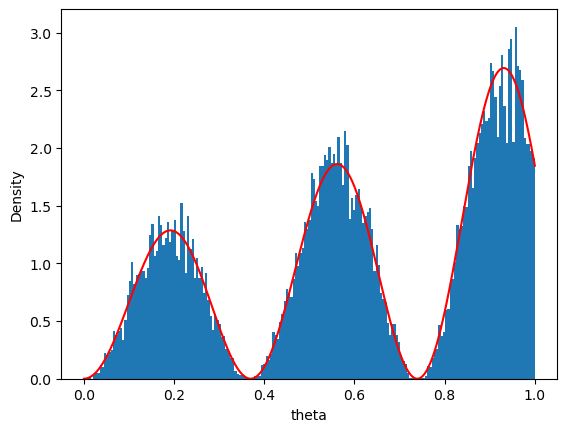

In [6]:
nit = 40000
path = np.empty(nit)
state = 0.4 #initialization
path[0] = state
rej = 0

for i in range(1, nit):
    candidate = np.random.normal(loc = state, scale = 0.3) #we are using sigma = 0.3
    ratio = f(candidate) / f(state)
    rnum = np.random.uniform(0, 1)
    if rnum >= ratio: 
        rej += 1
    else:
        state = candidate
    path[i] = state

print("Rejection rate:", rej / nit)

plt.hist(path, bins = 200, density = True)
plt.xlabel("theta")
plt.ylabel("Density")
plt.plot(th, f(th)/val, color = "red")
plt.show()

Below is the 'trace plot' (i.e., plot of $\theta^{(t)}$) for the last 2000 iterations. 

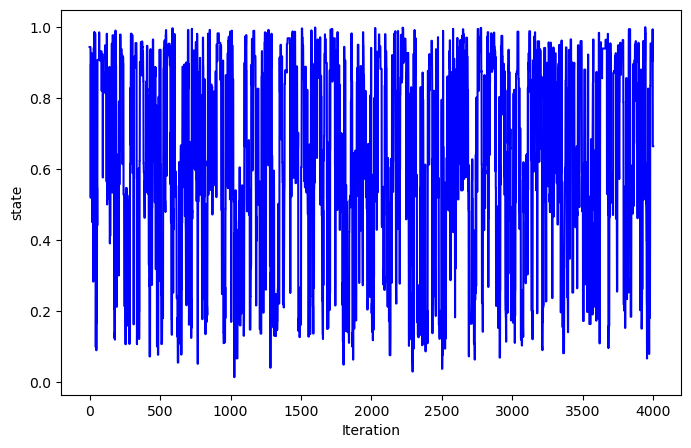

In [179]:
#Here are the last 4000 iterations of the path: 
plt.figure(figsize = (8, 5))
plt.plot(path[nit-4000:], color = "blue")
plt.xlabel("Iteration")
plt.ylabel("state")
plt.show()

This plot suggests that the chain is exploring all parts of the domain fairly well. Below, we plot the autocorrelations corresponding to the samples $\Theta^{(1)}, \dots, \Theta^{(N)}$. The autocorrelation at lag $h$ is essentially the sample correlation between $(\Theta^{(t)}, \Theta^{(t+h)})$ for $t = 1, \dots, N-h$. High autocorrelation values persisting for large lags is also an indication of poor mixing of the chain. 

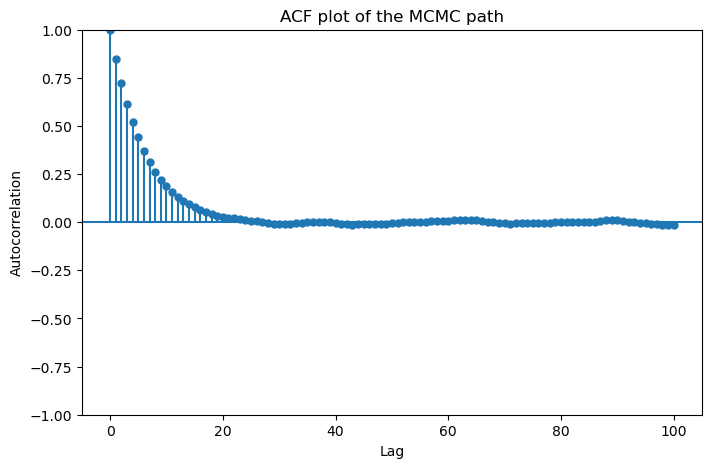

In [8]:
# Autocorrelation plot
plt.figure(figsize=(8,5))
plot_acf(path, lags=100, fft=True, alpha=None, ax=plt.gca())
plt.title("ACF plot of the MCMC path")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

Here the autocorrelations are decaying rapidly indicating good mixing. 

## A High-Dimensional Example

Next consider a $d$-dimensional problem where the true density is: 
\begin{align*}
   \pi(x_1, \dots, x_d) = f(x_1) \phi(x_2) \dots \phi(x_d)
\end{align*}
where $f(\cdot)$ is the univariate density that we saw above, and $\phi(\cdot)$ is the standard gaussian pdf. In other words, we have lifted the previous one-dimensional example to a larger dimension $d$ by including independent standard normal variables as the other coordinates. Below, we use RWM to draw samples from this $d$-dimensional density. We will evaluate the samples by only looking at the histograms and autocorrelations for the first coordinate. 

Rejection rate: 0.750775


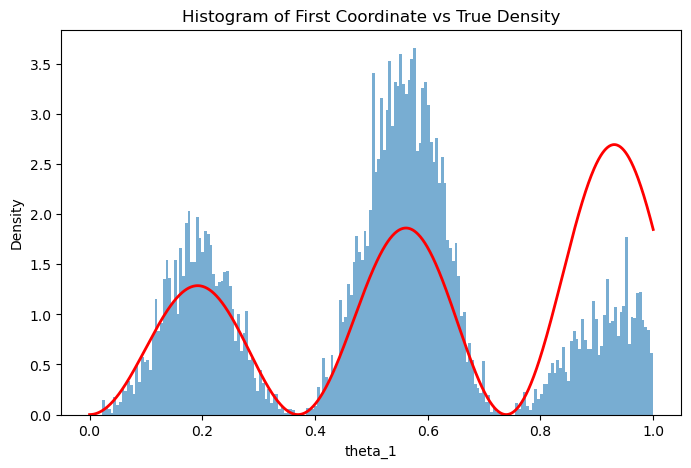

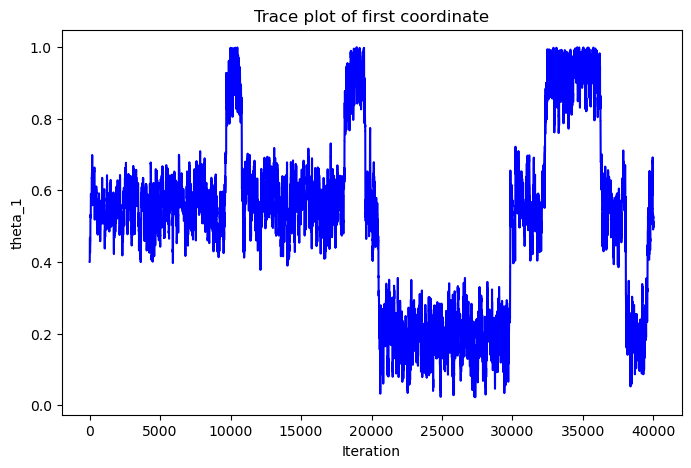

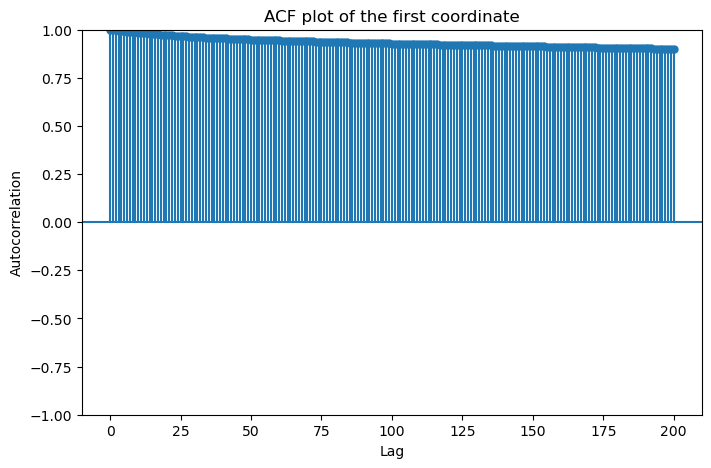

In [11]:
# log of standard normal density (up to constant)
def log_phi(x):
    return -0.5 * x**2

# dimension
d = 5000

# grid for plotting true density
th = np.arange(0, 1.001, 0.001)
f_vals = f(th)
val = np.trapezoid(f_vals, th)  # normalization for plotting

# RWM parameters
nit = 40000
path = np.empty(nit)  # store only first coordinate
state = np.zeros(d)
state[0] = 0.4  # initialize first coordinate
path[0] = state[0]

rej = 0
#try all the following step sizes and convince yourself that none of them work well (with N = 40000)
#step_size = 0.3  # this is WAY too big in high d
step_size = 0.03
#step_size = 0.01
#step_size = 0.01 #does not work
#step_size = 0.003 #this is too small

for i in range(1, nit):
    # propose full d-dimensional move
    candidate = state + np.random.normal(0, step_size, size=d)
    
    # compute log acceptance ratio
    log_ratio = 0.0
    
    # first coordinate contribution
    f_cand = f(candidate[0])
    f_curr = f(state[0])
    
    if f_cand == 0:
        log_ratio = -np.inf
    elif f_curr == 0:
        log_ratio = np.inf
    else:
        log_ratio += np.log(f_cand) - np.log(f_curr)
    
    # remaining coordinates (Gaussian)
    log_ratio += np.sum(log_phi(candidate[1:]) - log_phi(state[1:]))
    
    # accept/reject
    if np.log(np.random.uniform()) >= log_ratio:
        rej += 1
    else:
        state = candidate
    
    path[i] = state[0]

print("Rejection rate:", rej / nit)

# Histogram vs true density
plt.figure(figsize=(8,5))
plt.hist(path, bins=200, density=True, alpha=0.6)
plt.plot(th, f_vals / val, color="red", linewidth=2)
plt.xlabel("theta_1")
plt.ylabel("Density")
plt.title("Histogram of First Coordinate vs True Density")
plt.show()

# Trace plot of first coordinate
plt.figure(figsize=(8,5))
plt.plot(path, color="blue")
plt.xlabel("Iteration")
plt.ylabel("theta_1")
plt.title("Trace plot of first coordinate")
plt.show()

# Autocorrelation plot
plt.figure(figsize=(8,5))
plot_acf(path, lags=200, fft=True, alpha=None, ax=plt.gca())
plt.title("ACF plot of the first coordinate")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

Note that we are again drawing $N = 40000$ samples above (using RWM in $d = 5000$). It appears that no what we choose as the scale (or step size) $\sigma$, the resulting histogram of the first coordinate samples are somewhat far from the target $f$. This shows that, in this example, it is impossible to get a good estimate of the true density of the first coordinate using $N = 40000$ samples. For a better estimate, we would need to increase $N$ significantly. In the next lecture, we shall see how MALA works for this problem. 